#Requirements

In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import json
from skimage.exposure import match_histograms
import imagehash
from shapely.geometry import Polygon
from PIL import Image
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Dataset Pre-processing

In [4]:
def apply_threshold(img_gray):
  ret, thresh = cv.threshold(img_gray, 250.00, 255.00, int(cv.THRESH_OTSU))
  # plt.imshow(cv.cvtColor(thresh, cv.COLOR_BGR2RGB))
  # plt.title('After applying OTSU threshold')
  # plt.show()
  return thresh

In [5]:
def morphology(img_binary, kernel = np.ones((35, 35), np.uint8)):
  opening = cv.morphologyEx(img_binary, cv.MORPH_OPEN, kernel)
  closing = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)
  # plt.imshow(cv.cvtColor(closing, cv.COLOR_BGR2RGB))
  # plt.title('After applying morphology transformation')
  # plt.show()
  return closing

In [6]:
def crop_image(img, img_binary):
  temp = np.where(img_binary==255)
  crop_indexes = min(temp[0]) + 5, min(temp[1]) + 5
  mask = img_binary==255
  img_cropped = img[np.ix_(mask.any(1), mask.any(0))]
  img_cropped = img_cropped[5:-5, 5:-5]
  # plt.imshow(cv.cvtColor(img_cropped, cv.COLOR_BGR2RGB))
  # plt.title('After cropping_image')
  # plt.show()
  return img_cropped, crop_indexes

In [7]:
def histogram_matching(img_cropped, pattern):
  m = match_histograms(img_cropped, pattern, multichannel=True)
  # plt.imshow(cv.cvtColor(m, cv.COLOR_BGR2RGB))
  # plt.title('After histogram matching')
  # plt.show()
  return m

In [8]:
def rotate_finder(img_matched,pattern_resized):
    simil = []
    
    img = cv.cvtColor(img_matched, cv.COLOR_BGR2RGB)
    im_pil1 = Image.fromarray(img)
    hash = imagehash.average_hash(im_pil1)
    rotate = [None,cv.ROTATE_90_CLOCKWISE,cv.ROTATE_180,cv.ROTATE_90_COUNTERCLOCKWISE]

    
    for angle in rotate:
        if angle != None:
            img = cv.cvtColor(cv.rotate(pattern_resized, angle), cv.COLOR_BGR2RGB)
            im_pil2 = Image.fromarray(img)
            hash_ = imagehash.average_hash(im_pil2)
            simil.append(hash - hash_)
        else:
            im_pil2 = Image.fromarray(pattern_resized)
            hash_ = imagehash.average_hash(im_pil2)
            simil.append(hash - hash_)
    indx = rotate[simil.index(min(simil))]
    hold = cv.rotate(pattern_resized, indx)
    
    if hold.shape[0] != img_matched.shape[0]:
        hold = cv.resize(hold, (hold.shape[1], hold.shape[0]))
    
    return hold
    

In [9]:
def extract_pattern(img_name):
    json_name = img_name[:-3] + "json"
    f = open(json_name, encoding="utf8")
    data = json.load(f)
    f.close()
    pattern = cv.imread('Patterns/' + data['pattern'])
    return pattern

In [10]:
def find_label(img_name,i,window_size_height, j,window_size_width,main):
    not_main = Polygon([(i,j),(i+window_size_height,j),(i+window_size_height,j+window_size_width),(i,j+window_size_width)]).buffer(0)
    Flag = 0
    inter = not_main.intersection(main).area
    if inter > 0:
        return 1
    return 0

In [11]:
def window_sliding(img, pattern, img_name, crop_indexes, window_size_height=120, window_size_width=120):
  images, patterns, labels = [], [], []
  height, width= img.shape
  point_list = []
  json_name = img_name[:-3] + "json"
  f = open(json_name, encoding="utf8")
  data = json.load(f)
  f.close()
  for shape in data["shapes"]:
    points = np.array(shape['points']) - crop_indexes
    for pxl in points:
        point_list.append((int(pxl[0]),int(pxl[1])))
  main = Polygon(point_list).buffer(0)
        
  for i in range(0, height-window_size_height, window_size_height):
    for j in range(0, width-window_size_width, window_size_width):
      # cv.imwrite(dir +'/' + str(i)+str(j)+'_img_'+img_name, img_part)
      # cv.imwrite(dir +'/' + str(i)+str(j)+'_pattern_'+img_name, pattern_part)
      temp = pattern[i:i+window_size_height, j:j+window_size_width]
      if temp.shape==(window_size_height, window_size_width):
        patterns.append(temp)
        images.append(img[i:i+window_size_height, j:j+window_size_width])
        labels.append(find_label(img_name,i,window_size_height, j,window_size_width,main))
  return images, patterns, labels

In [23]:
def save_image(img_name, img_matched, pattern_resized_rotate, crop_indexes, dir='Customized_Dataset/'):
  if not os.path.exists(dir):
    os.mkdir(dir)
  json_name = img_name[:-3] + "json"
  f = open(json_name, encoding="utf8")
  data = json.load(f)
  f.close()
  img_name = img_name.replace('Dataset/', '')
  new_json_name = dir + img_name[:-4] + '_customized' + ".json"
  for i in range(len(data["shapes"])):
    data['shapes'][i]['points'] = np.array(data['shapes'][i]['points']) - crop_indexes
    data['shapes'][i]['points'] = data['shapes'][i]['points'].tolist()
  with open(new_json_name, 'w') as fp:
        json.dump(data, fp)
  
  cv.imwrite(dir + 'customized_img_'+img_name, img_matched)
  cv.imwrite(dir + 'customized_pattern_'+img_name, pattern_resized_rotate)

In [24]:
def pre_processing(img_name,Kernel_size = 120):
  img = cv.imread(img_name).astype('uint8')
  img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
  img_binary = apply_threshold(img_gray)
  img_binary = morphology(img_binary)
  img_cropped, crop_indexes = crop_image(img, img_binary)
  pattern = extract_pattern(img_name)
  img_matched = histogram_matching(img_cropped, pattern)
  pattern_resized = cv.resize(pattern, (img_matched.shape[1], img_matched.shape[0]))
  pattern_resized_rotate = rotate_finder(img_matched,pattern_resized)
  save_image(img_name, img_matched, pattern_resized_rotate, crop_indexes)
  img_matched, pattern_resized_rotate = cv.cvtColor(img_matched, cv.COLOR_BGR2GRAY), cv.cvtColor(pattern_resized_rotate, cv.COLOR_BGR2GRAY)
  images, patterns, labels = window_sliding(img_matched, pattern_resized_rotate, img_name, crop_indexes,Kernel_size,Kernel_size)
  return images,patterns,labels

In [25]:
images, patterns, labels = [], [], []
j=0
for img in os.listdir('Dataset'):
    if (img.endswith(".jpg")) | (img.endswith(".png")):
        i,p,l = pre_processing('Dataset/' + img)
        images.extend(i)
        patterns.extend(p)
        labels.extend(l)
        j += 1
        print(j, 'done!')
    # if j==5:
    #     break

Customized_Dataset/customized_1644448758.2149394.png
Dataset/1644448758.2149394.png done!
Customized_Dataset/customized_1644442073.9465039.png
Dataset/1644442073.9465039.png done!
Customized_Dataset/customized_1644449241.8868785.png
Dataset/1644449241.8868785.png done!
Customized_Dataset/customized_1644426961.8556552.png
Dataset/1644426961.8556552.png done!
Customized_Dataset/customized_1644428265.7917786.png
Dataset/1644428265.7917786.png done!


In [19]:
images = np.expand_dims(np.array(images).astype(np.float32), axis=3)
patterns= np.expand_dims(np.array(patterns).astype(np.float32), axis=3)
labels = np.expand_dims(np.array(labels).astype(np.float32), axis=1)

In [20]:
len(patterns)

14448

In [21]:
labels[labels==0].shape[0]/labels[labels==1].shape[0]

58.70247933884298

In [22]:
from keras import backend as K

# Model

In [23]:
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + 
    K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_score_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [54]:
# Provided two tensors t1 and t2
# Euclidean distance = sqrt(sum(square(t1-t2)))
def euclidean_distance(vects):
    """Find the Euclidean distance between two vectors.

    Arguments:
        vects: List containing two tensors of same length.

    Returns:
        Tensor containing euclidean distance
        (as floating point value) between vectors.
    """

    x, y = vects
    sum_square = tf.math.reduce_sum(tf.math.square(x - y), axis=1, keepdims=True)
    return tf.math.sqrt(tf.math.maximum(sum_square, tf.keras.backend.epsilon()))


input = layers.Input((120, 120, 1))
x = tf.keras.layers.BatchNormalization()(input)
x = layers.Conv2D(4, (5, 5), activation="tanh")(x)
x = layers.AveragePooling2D(pool_size=(2, 2))(x)
x = layers.Conv2D(16, (5, 5), activation="tanh")(x)
x = layers.AveragePooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)

x = tf.keras.layers.BatchNormalization()(x)
x = layers.Dense(10, activation="tanh")(x)
embedding_network = keras.Model(input, x)


input_1 = layers.Input((120, 120, 1))
input_2 = layers.Input((120, 120, 1))

# As mentioned above, Siamese Network share weights between
# tower networks (sister networks). To allow this, we will use
# same embedding network for both tower networks.
tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = layers.Lambda(euclidean_distance)([tower_1, tower_2])
normal_layer = tf.keras.layers.BatchNormalization()(merge_layer)
output_layer = layers.Dense(1, activation="sigmoid")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)


In [55]:
def loss(margin=1):
    """Provides 'constrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'constrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the constrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing constrastive loss as floating point value.
        """

        square_pred = tf.math.square(y_pred)
        margin_square = tf.math.square(tf.math.maximum(margin - (y_pred), 0))
        return tf.math.reduce_mean(
            (1 - y_true) * square_pred + (y_true) * margin_square
        )

    return contrastive_loss


In [56]:
siamese.compile(loss=loss(margin=1), optimizer="RMSprop", metrics=['accuracy',recall_m,precision_m,f1_score_m])
siamese.summary()

Model: "model_11"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_17 (InputLayer)           [(None, 120, 120, 1) 0                                            
__________________________________________________________________________________________________
input_18 (InputLayer)           [(None, 120, 120, 1) 0                                            
__________________________________________________________________________________________________
model_10 (Functional)           (None, 10)           165030      input_17[0][0]                   
                                                                 input_18[0][0]                   
__________________________________________________________________________________________________
lambda_5 (Lambda)               (None, 1)            0           model_10[0][0]            

In [57]:
class_weight = {0: 1, 1: (10*labels[labels==0].shape[0]/labels[labels==1].shape[0])}

history = siamese.fit(
    [images, patterns],
    labels,
    # validation_data=([x_val_1, x_val_2], labels_val),
    batch_size=1024,
    epochs=500,
    validation_split=0.2,
    callbacks=keras.callbacks.EarlyStopping(monitor='val_f1_score_m',
                                            patience=5,
                                            restore_best_weights=True),
    class_weight =class_weight
)

Epoch 1/500
12/12 [==============================] - 34s 3s/step - loss: 3.2109 - accuracy: 0.5659 - recall_m: 0.6018 - precision_m: 0.0206 - f1_score_m: 0.0397 - val_loss: 0.3407 - val_accuracy: 0.0266 - val_recall_m: 1.0000 - val_precision_m: 0.0204 - val_f1_score_m: 0.0400
Epoch 2/500
12/12 [==============================] - 33s 3s/step - loss: 2.9660 - accuracy: 0.6291 - recall_m: 0.6603 - precision_m: 0.0259 - f1_score_m: 0.0496 - val_loss: 0.4220 - val_accuracy: 0.0436 - val_recall_m: 1.0000 - val_precision_m: 0.0208 - val_f1_score_m: 0.0408
Epoch 3/500
12/12 [==============================] - 33s 3s/step - loss: 2.7829 - accuracy: 0.6760 - recall_m: 0.6918 - precision_m: 0.0341 - f1_score_m: 0.0648 - val_loss: 0.4835 - val_accuracy: 0.0699 - val_recall_m: 1.0000 - val_precision_m: 0.0215 - val_f1_score_m: 0.0420
Epoch 4/500
12/12 [==============================] - 33s 3s/step - loss: 2.7144 - accuracy: 0.6939 - recall_m: 0.6982 - precision_m: 0.0364 - f1_score_m: 0.0691 - val_lo

In [61]:
from tensorflow.keras.applications import resnet
base_cnn = resnet.ResNet50(
    weights="imagenet", input_shape=(120,120,3), include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5: 403 -- Forbidden

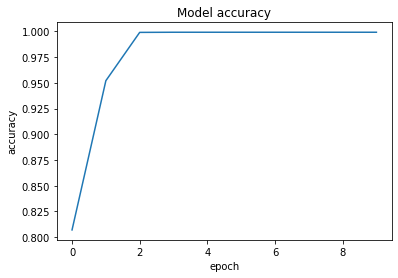

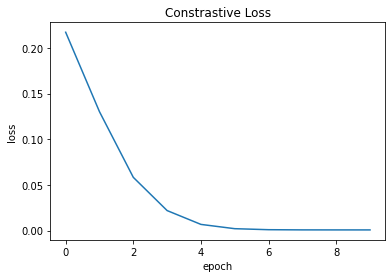

In [24]:
def plt_metric(history, metric, title, has_valid=False):
    """Plots the given 'metric' from 'history'.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()


# Plot the accuracy
plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

# Plot the constrastive loss
plt_metric(history=history.history, metric="loss", title="Constrastive Loss")

In [ ]:
predictions = siamese.predict([x_test_1, x_test_2])
visualize(pairs_test, labels_test, to_show=3, predictions=predictions, test=True)